# Two-Time-Scale Coupling Demonstration: `ZrMicro` 0-D $\leftrightarrow$ spatially-resolved SR-CD

This notebook demonstrates the **operator-split QSSA** coupling scheme formulated in
[`../Docs/Formulation/ZrMicro_MoDELib2_two_time_scale_coupling.tex`](../Docs/Formulation/ZrMicro_MoDELib2_two_time_scale_coupling.tex)
(see the section *Adopted Implementation: Operator-Split QSSA*).

**What runs here (with the existing codebase):**
1. The `ZrMicro` 0-D cluster-dynamics solver provides the well-mixed reference and the bulk mobile field.
2. A spatial line of *quadrature points* spans a grain interior to a perfect-sink grain boundary.
3. The **slow immobile manifold** is marched in dose at every point with the *real* `freeze_mobile`
   micro-model (`py_utils/modelib_coupling.run_immobile_step`, one OpenMP batch case per point).

**What is a placeholder (to be replaced by the 3-D code):**
- The **fast mobile FEM solve** $\mathcal{R}_M(C_M^\star;Q)=0$ is stood in by an analytic boundary-layer
  depletion of the bulk mobile field, $C_M^\star(x)=f(x)\,C_M^{\text{bulk}}$ with
  $f(x)=1-e^{-x/\ell}$. **This is exactly the step that
  [`MoDELib2-NNL`](https://github.com/mlm335/MoDELib2-NNL) replaces** with a real finite-element
  reaction–diffusion solve.

**Expected result:** the interior reproduces the 0-D model (regression), while a *denuded zone*
develops near the grain boundary — physics the 0-D model cannot capture.

In [2]:
import os, sys, types
import numpy as np
import matplotlib.pyplot as plt

# Resolve the ZrMicro root so input/ and py_utils/ import correctly,
# whether launched from ZrMicro/ or elsewhere.
from pathlib import Path as _P
HERE = _P.cwd()
if not ((HERE / "py_utils").is_dir() and (HERE / "input").is_dir()):
    # Locate ZrMicro/ inside the DisloCluster repository, from wherever the
    # kernel was started -- no hard-coded absolute path.
    for _c in (HERE, *HERE.parents):
        for _rel in (("ZrMicro",), ("ZrClusterDynamics", "ZrMicro")):
            _z = _c.joinpath(*_rel)
            if (_z / "py_utils").is_dir() and (_z / "input").is_dir():
                os.chdir(_z)
                break
        else:
            continue
        break
    else:
        raise RuntimeError(f"Cannot locate ZrMicro/ from {HERE}")
sys.path.insert(0, os.getcwd())
print("ZrMicro root:", os.getcwd())

from py_utils.input_data import InputData
from py_utils.reaction_rates import ReactionRates
from py_utils.rate_equations import RateEquations
from py_utils.cpp_bridge import collect_solver_args, run_cpp_solver
from py_utils.modelib_coupling import pack_y0, run_immobile_step
from py_utils import modelib_export
from py_utils.modelib_fem import MoDELibFEMSolver      # real FEM bridge (Section 4/7)

ZrMicro root: d:\GitHub\ZrClusterDynamics\ZrMicro


## 1. Initialize the 0-D `ZrMicro` model

Load material/environment parameters and build the `InputData → ReactionRates → RateEquations`
chain, exactly as a standalone 0-D run does. `base_cli` is the shared command-line parameter
set the C++ solver receives; because $T,\sigma$ and the sink/bias parameters are spatially
**uniform** in this demo, one `base_cli` serves every quadrature point.

In [3]:
idata = InputData()
rr    = ReactionRates(idata)
re    = RateEquations(idata, rr)
sim   = types.SimpleNamespace(input_data=idata, reaction_rates=rr,
                              rate_equations=re, input_file="input/Zr_input_parameters.xlsx")

G     = float(idata.material_params['G'])         # dose rate [dpa/s]
A_a   = float(idata.model_params['A_a'])
A_c   = float(idata.model_params['A_c'])
Omega = float(idata.physical_props['Omega'])
print(f"T = {idata.material_params['T']} K   G = {G:.2e} dpa/s   A_a={A_a}  A_c={A_c}")

base_cfg = dict(t_begin=1e-1, t_end=1.0/G, n_points=300,
                rtol=1e-6, atol=1e-20, log_time=True)
base_cli = collect_solver_args(sim, base_cfg)

InputData: Attempting to load d:\GitHub\ZrClusterDynamics\ZrMicro\input\Zr_input_parameters.xlsx
✓ File exists: d:\GitHub\ZrClusterDynamics\ZrMicro\input\Zr_input_parameters.xlsx
Reading Excel file: d:\GitHub\ZrClusterDynamics\ZrMicro\input\Zr_input_parameters.xlsx
✓ Successfully loaded input data from Excel file
  DAD bias: Z_i_a=1.109 Z_v_a=0.800 Z_i_c=0.891 Z_v_c=1.200
Derived f: 0.051779227125179204, f_a: 0.3678528180834528, f_na: 0.6321471819165472
✓ Derived parameters calculated successfully
  C_v_eq = 8.45e-15
  G_v = 9.80e-08
  G_i = 8.93e-08
  rho(T=573K) = 1.88e+14 m^-2
Initialized rate equations system with 19 equations (12 physical + 6 conservation accumulators + 1 evolving rho_N)
  C_floor = 1.00e-20
T = 573.0 K   G = 1.00e-07 dpa/s   A_a=1.0  A_c=1.0


## 2. 0-D reference (well-mixed limit)

Run the full 0-D model once. It supplies (a) the **regression reference** the spatial interior
must reproduce, and (b) the **bulk mobile field** $C_M^{\text{bulk}}(\gamma)$ that the placeholder
fast-solve depletes near the boundary. We build dose-indexed interpolators for the mobile species,
the native immobile state, and $\rho_N$.

In [4]:
ref = run_cpp_solver(sim, base_cfg)
assert ref is not None, "0-D reference run failed (build solver.exe in cpp_utils first)"

ref_dose = G * np.asarray(ref['time'])
C = ref['concentrations']
MOB = ('Cv','Ci','C2i','C3i')
IMM = ('CiL','CaiL','CvL','CavL','CiL_i','CaiL_i','CvL_v','CavL_v')   # native layout

def refmob(d):  return np.array([np.interp(d, ref_dose, C[n]) for n in MOB])
def refimm(d):  return np.array([np.interp(d, ref_dose, C[n]) for n in IMM])
def refrho(d):  return float(np.interp(d, ref_dose, ref['rho_N']))

def eps_from_y(y):    # full 19-vector: loop CONTENTS at 8,9,10,11
    return A_a*(y[8]+y[9]), -A_c*(y[10]+y[11])
def eps_from_ref(d):  # 0-D 8-vector: contents at 4,5,6,7
    im = refimm(d);  return A_a*(im[4]+im[5]), -A_c*(im[6]+im[7])

print("0-D at 1 dpa:  eps_a =", f"{eps_from_ref(1.0)[0]:.3e}",
      "  Cv_bulk =", f"{refmob(1.0)[0]:.3e}")

Running C++ solver (solver.exe) ...
✓ C++ solver completed — 300 time points
Calculating derived quantities (vectorized)...
✓ Derived quantities calculated.
  Conservation (final): interstitial rel.err = +3.39e-13, vacancy rel.err = +1.55e-12
✓ Results processing complete!
0-D at 1 dpa:  eps_a = 3.557e-01   Cv_bulk = 6.060e-06


## 3. Spatial grid and the placeholder fast solve

A line of `Npts` quadrature points spans $x\in[0,L]$ with a **perfect-sink grain boundary at $x=0$**.
The mobile depletion length is estimated from the network sink strength,
$\ell=1/\sqrt{Z_N\rho_N}$, and the domain is sized to a few $\ell$ so the boundary layer is resolved.

The placeholder fast solve is
$$C_M^\star(x) = f(x)\,C_M^{\text{bulk}}, \qquad f(x)=1-e^{-x/\ell},$$
so $f=0$ at the boundary (full depletion) and $f\to1$ in the interior. **MoDELib2-NNL replaces this
single line** with a finite-element reaction–diffusion solve that resolves each species' real
boundary layer and the loop-sink feedback.

In [5]:
rho0 = float(idata.material_params['rho'])
Z_N  = float(idata.model_params.get('Z_N', 1.1))
ell  = 1.0/np.sqrt(Z_N*rho0)                  # depletion length [m]
L    = 12*ell
Npts = 25
x      = np.linspace(0.0, L, Npts)
f_depl = 1.0 - np.exp(-x/ell)                 # 0 at GB -> 1 interior
print(f"depletion length ell = {ell*1e9:.1f} nm   L = {L*1e9:.0f} nm   Npts = {Npts}")

depletion length ell = 69.5 nm   L = 834 nm   Npts = 25


## 4. Operator-split dose march (the adopted scheme)

For each dose step $[\gamma_n,\gamma_{n+1}]$:

1. **Fast solve:** refresh the frozen mobile field $C_M^\star(x_q)$ at every point — via
   `fast_solve_field(...)` below, which switches on `FAST_SOLVE_BACKEND`:
   - `"placeholder"` (default, runs now): analytic boundary layer $C_M^\star(x)=f(x)\,C_M^{\text{bulk}}$;
   - `"modelib"`: the **real** finite-element solve through `MoDELibFEMSolver` (`py_utils/modelib_fem.py`),
     which writes the loop sink field into MoDELib's `inputFiles/`, runs `DDomp`, and reads back
     $C_M^\star(\mathbf{x})$ on the mesh. Active once MoDELib2-NNL is built (see Section 7); otherwise
     the cell reports it is unavailable and falls back to the placeholder.
2. **Slow march (real):** advance the immobile state at all points with `run_immobile_step`
   — the `freeze_mobile=1` ZrMicro micro-model, one OpenMP batch case per point.

The immobile state is seeded at $\gamma_0$ from the 0-D reference. `march_all` substeps each
dose interval (the §"Splitting error and dose-step control" cap) so the stiff integrator stays
robust; the mobile stays frozen across the whole macro-step.

In [6]:
# --- fast-solve backend selector --------------------------------------------
FAST_SOLVE_BACKEND = "placeholder"            # "placeholder" (runs now) | "modelib"
# Resolved from the repository layout by py_utils/paths.py; override with
# the MODELIB_ROOT / MODELIB_BUILD environment variables.
from py_utils import paths
MODELIB_ROOT  = str(paths.MODELIB_ROOT)      # DisloCluster/MoDELib3 (templates, Zr material)
MODELIB_BUILD = str(paths.MODELIB_BUILD)     # where DDomp / pyMoDELib land once built

femsolver = MoDELibFEMSolver(sim_dir=os.path.join(os.getcwd(), "output", "modelib_sim"),
                             modelib_root=MODELIB_ROOT, modelib_build_dir=MODELIB_BUILD)
print("MoDELib FEM bridge available:", femsolver.available(),
      "(DDomp:", femsolver.find_ddomp(), ")")

def fast_solve_field(dose):
    # Return the steady mobile field C_M*[Npts,4] at the current dose.
    if FAST_SOLVE_BACKEND == "modelib" and femsolver.available():
        # Real FEM solve: build the per-variant sink field, run MoDELib, read back.
        # NB: the real coupling marches on MoDELib's 3-D mesh quadrature points, not
        # this illustrative 1-D line; see Section 7 for the geometry swap.
        raise NotImplementedError("activate after building MoDELib (Section 7)")
    CMb = refmob(dose)                         # placeholder: analytic boundary layer
    return f_depl[:, None] * CMb[None, :]


MoDELib FEM bridge available: False (DDomp: None )


In [7]:
doses = np.array([0.01,0.02,0.05,0.1,0.2,0.3,0.5,0.7,1.0])
times = doses / G

def march_all(Y, t0, t1, max_dt=5e4):
    # Advance all points over [t0,t1] with frozen mobile; substep for robustness.
    nsub  = max(1, int(np.ceil((t1-t0)/max_dt)))
    edges = np.linspace(t0, t1, nsub+1)
    for a, b in zip(edges[:-1], edges[1:]):
        out = run_immobile_step(base_cli, Y, a, b)
        n_fail = sum(o is None for o in out)
        if n_fail:
            print(f"    warning: {n_fail} point(s) failed on [{a:.2e},{b:.2e}] (kept previous)")
        Y = [o if o is not None else y for o, y in zip(out, Y)]
    return Y

# seed Q at dose[0] from the 0-D reference (uniform across points)
im0, rho0_seed = refimm(doses[0]), refrho(doses[0])
CM0 = fast_solve_field(doses[0])
Y = [pack_y0(CM0[q], im0.copy(), rho0_seed) for q in range(Npts)]

hist = {doses[0]: np.array([y.copy() for y in Y])}
for n in range(len(doses)-1):
    CM = fast_solve_field(doses[n])             # <-- fast solve (placeholder or MoDELib)
    for q in range(Npts):
        Y[q][0:4] = CM[q]                       # inject local frozen mobile
    Y = march_all(Y, times[n], times[n+1])
    hist[doses[n+1]] = np.array([y.copy() for y in Y])
    print(f"  marched to {doses[n+1]:.2f} dpa")

  marched to 0.02 dpa
  marched to 0.05 dpa
  marched to 0.10 dpa
  marched to 0.20 dpa
  marched to 0.30 dpa
  marched to 0.50 dpa
  marched to 0.70 dpa
  marched to 1.00 dpa


## 5. Results

**Regression:** the interior point must track the 0-D reference (well-mixed limit).
**New physics:** a denuded zone near the grain boundary, absent from the 0-D model.

In [8]:
final = hist[doses[-1]]                              # (Npts, 19)
eps_a_x = np.array([eps_from_y(final[q])[0] for q in range(Npts)])
Na_x    = (final[:,4]+final[:,5])/Omega              # a-loop number density [m^-3]

ea_int, _ = eps_from_y(final[-1])                    # interior point
ea_0D , _ = eps_from_ref(doses[-1])                  # 0-D reference
print(f"INTERIOR eps_a = {ea_int:.4e}   0-D eps_a = {ea_0D:.4e}   "
      f"rel.diff = {abs(ea_int-ea_0D)/abs(ea_0D):.2%}   (regression)")
print(f"BOUNDARY eps_a = {eps_a_x[0]:.4e}   "
      f"= {eps_a_x[0]/max(ea_int,1e-30):.1%} of interior (denuded zone)")

INTERIOR eps_a = 3.4438e-01   0-D eps_a = 3.5568e-01   rel.diff = 3.18%   (regression)
BOUNDARY eps_a = 1.0339e-01   = 30.0% of interior (denuded zone)


findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not

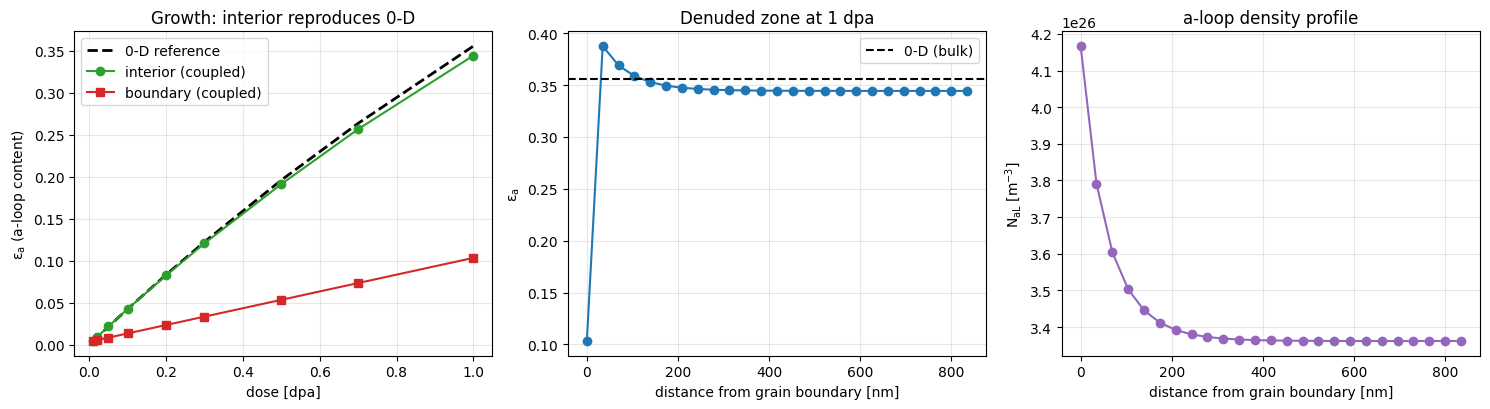

saved output/coupling_demo.png


In [9]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))

# (a) eps_a vs dose: interior vs boundary vs 0-D
d_axis = np.array(sorted(hist))
ea_interior = [eps_from_y(hist[d][-1])[0] for d in d_axis]
ea_boundary = [eps_from_y(hist[d][0])[0]  for d in d_axis]
ea_ref      = [eps_from_ref(d)[0]         for d in d_axis]
ax[0].plot(d_axis, ea_ref,      'k--', lw=2, label='0-D reference')
ax[0].plot(d_axis, ea_interior, 'o-',  color='tab:green', label='interior (coupled)')
ax[0].plot(d_axis, ea_boundary, 's-',  color='tab:red',   label='boundary (coupled)')
ax[0].set_xlabel('dose [dpa]'); ax[0].set_ylabel(r'$\varepsilon_a$ (a-loop content)')
ax[0].set_title('Growth: interior reproduces 0-D'); ax[0].legend(); ax[0].grid(alpha=.3)

# (b) eps_a(x) profile at final dose
ax[1].plot(x*1e9, eps_a_x, 'o-', color='tab:blue')
ax[1].axhline(ea_0D, ls='--', color='k', label='0-D (bulk)')
ax[1].set_xlabel('distance from grain boundary [nm]'); ax[1].set_ylabel(r'$\varepsilon_a$')
ax[1].set_title(f'Denuded zone at {doses[-1]:.0f} dpa'); ax[1].legend(); ax[1].grid(alpha=.3)

# (c) a-loop number density profile
ax[2].plot(x*1e9, Na_x, 'o-', color='tab:purple')
ax[2].set_xlabel('distance from grain boundary [nm]'); ax[2].set_ylabel(r'$N_{a\mathcal{L}}$ [m$^{-3}$]')
ax[2].set_title('a-loop density profile'); ax[2].grid(alpha=.3)

plt.tight_layout()
os.makedirs('output', exist_ok=True)
fig.savefig('output/coupling_demo.png', dpi=120)
plt.show()
print('saved output/coupling_demo.png')

## 6. Export the closure table for `MoDELib2-NNL`

Serialize the 0-D run as the dose-indexed table the 3-D code consumes
(`py_utils/modelib_export.py`): the crystallographically resolved `a1/a2/a3`+`c` loop fields,
sink strengths, $\rho_N$, $n_v$, plus $\varepsilon_a,\varepsilon_c$ for the regression check.

In [10]:
out_dir = 'output/modelib_closure'
tbl, meta = modelib_export.export_for_modelib(ref, idata, out_dir)   # zero stress -> w_k = 1/3
print('table:', tbl)
print('meta :', meta)

✓ MoDELib export: output\modelib_closure\modelib_cd_table.txt  (300 dose rows, 26 columns)
✓ MoDELib metadata: output\modelib_closure\modelib_cd_meta.json
table: output\modelib_closure\modelib_cd_table.txt
meta : output\modelib_closure\modelib_cd_meta.json


## 7. Coupling to `MoDELib2-NNL` — status and how to activate

The 3-D code lives inside this repository at `DisloCluster/MoDELib3/` (resolved by
`py_utils.paths.MODELIB_ROOT`) and the coupling interface is **mapped and
wired**: the bridge `py_utils/modelib_fem.py` (`MoDELibFEMSolver`) writes the ZrMicro loop sink
field into MoDELib's `inputFiles/` (`aLoopsDensity.txt` for $a_1,a_2,a_3$, `frankLoopsDensity.txt`
for $\langle c\rangle$), runs the FEM solve (`DDomp <simDir>`, or `pyMoDELib` in-process), and reads
back $C_M^\star(\mathbf{x})$. Section 4 already calls it via `FAST_SOLVE_BACKEND="modelib"`.

**What blocks running it here:** MoDELib2-NNL is a C++20 library built with **GCC/Clang**
(`-Ofast -march=native -fopenmp`) and needs Eigen + pybind11 (+ optional Boost/SuiteSparse/FFTW).
This Windows box has only MSVC (which rejects those flags) — no GCC/Clang/MinGW/WSL — and the repo's
`CMakeLists.txt` hardcodes macOS paths. So the final build must happen on Linux/macOS (or after
installing a GCC/Clang toolchain + adapting CMake). The full recipe and interface map are in
[`../Docs/Formulation/MoDELib_build_and_coupling_notes.md`](../Docs/Formulation/MoDELib_build_and_coupling_notes.md).

**To activate once built:**
1. Build MoDELib (`DDomp` + `pyMoDELib`) per the notes; set `MODELIB_BUILD` in Section 4.
2. Seed a sim dir: `MoDELibFEMSolver(...).seed_sim_dir_from_tutorial(...)`, then run the tutorial's
   `generateInputFiles.py` once (uses the `Zr4` material, `unitCube_15K.msh` mesh, 553 K).
3. Switch `FAST_SOLVE_BACKEND="modelib"`. The march then runs on MoDELib's 3-D mesh quadrature
   points (replace this notebook's illustrative 1-D line accordingly); the per-point
   `run_immobile_step` slow micro-model is unchanged.
4. **Verify** against this notebook's well-mixed regression (interior $\approx$ 0-D), then activate
   spatial gradients, finite-rate sinks, and stress per the staged plan in the formulation.